In [14]:
using LinearAlgebra
using Distributions
using LaTeXStrings
using Printf
using FileIO
import JLD2

In [15]:
using DataFrames

In [16]:
using Revise
using Newtrinos
using Newtrinos.osc

In [17]:
osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NNM(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

Newtrinos.osc.Osc(OscillationConfig{NNM, SI, Basic, Newtrinos.osc.All}(NNM(ThreeFlavour(:NO)), SI(), Basic(), Newtrinos.osc.All()), (m₀ = 0.1, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761, δCP = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, N = 20.0, r = 1.0), (m₀ = Uniform{Float64}(a=1.0e-7, b=0.3), θ₁₂ = Uniform{Float64}(a=0.4205343352839651, b=0.7853981633974483), θ₁₃ = Uniform{Float64}(a=0.1, b=0.2), θ₂₃ = Uniform{Float64}(a=0.5235987755982988, b=1.0471975511965976), δCP = Uniform{Float64}(a=0.0, b=6.283185307179586), Δm²₂₁ = Uniform{Float64}(a=6.5e-5, b=9.0e-5), Δm²₃₁ = Uniform{Float64}(a=0.002, b=0.003), N = Uniform{Float64}(a=1.0, b=40.0), r = Uniform{Float64}(a=1.0e-8, b=1.5)), Newtrinos.osc.var"#get_Nnaturalness#53"(), Newtrinos.osc.var"#osc_prob#43"{Newtrinos.osc.var"#osc_prob#41#44"{OscillationConfig{NNM, SI, Basic, Newtrinos.osc.All}}}(Newtrinos.osc.var"#osc_prob#41#44"{OscillationConfig{NNM, SI, Basic, Newtrinos.osc.All}}(OscillationC

In [18]:

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics = (; osc, atm_flux, earth_layers);

In [19]:
experiments = (
 
    dayabay = Newtrinos.dayabay.configure(physics),
);

[ Info: Loading dayabay data


In [20]:
p = Newtrinos.get_params(experiments)

(N = 20.0, m₀ = 0.1, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

gamma[1.0, 1.0037579389474338, 1.1169288249481253]
scale0.1
Condition number: 9.902566190272577e7


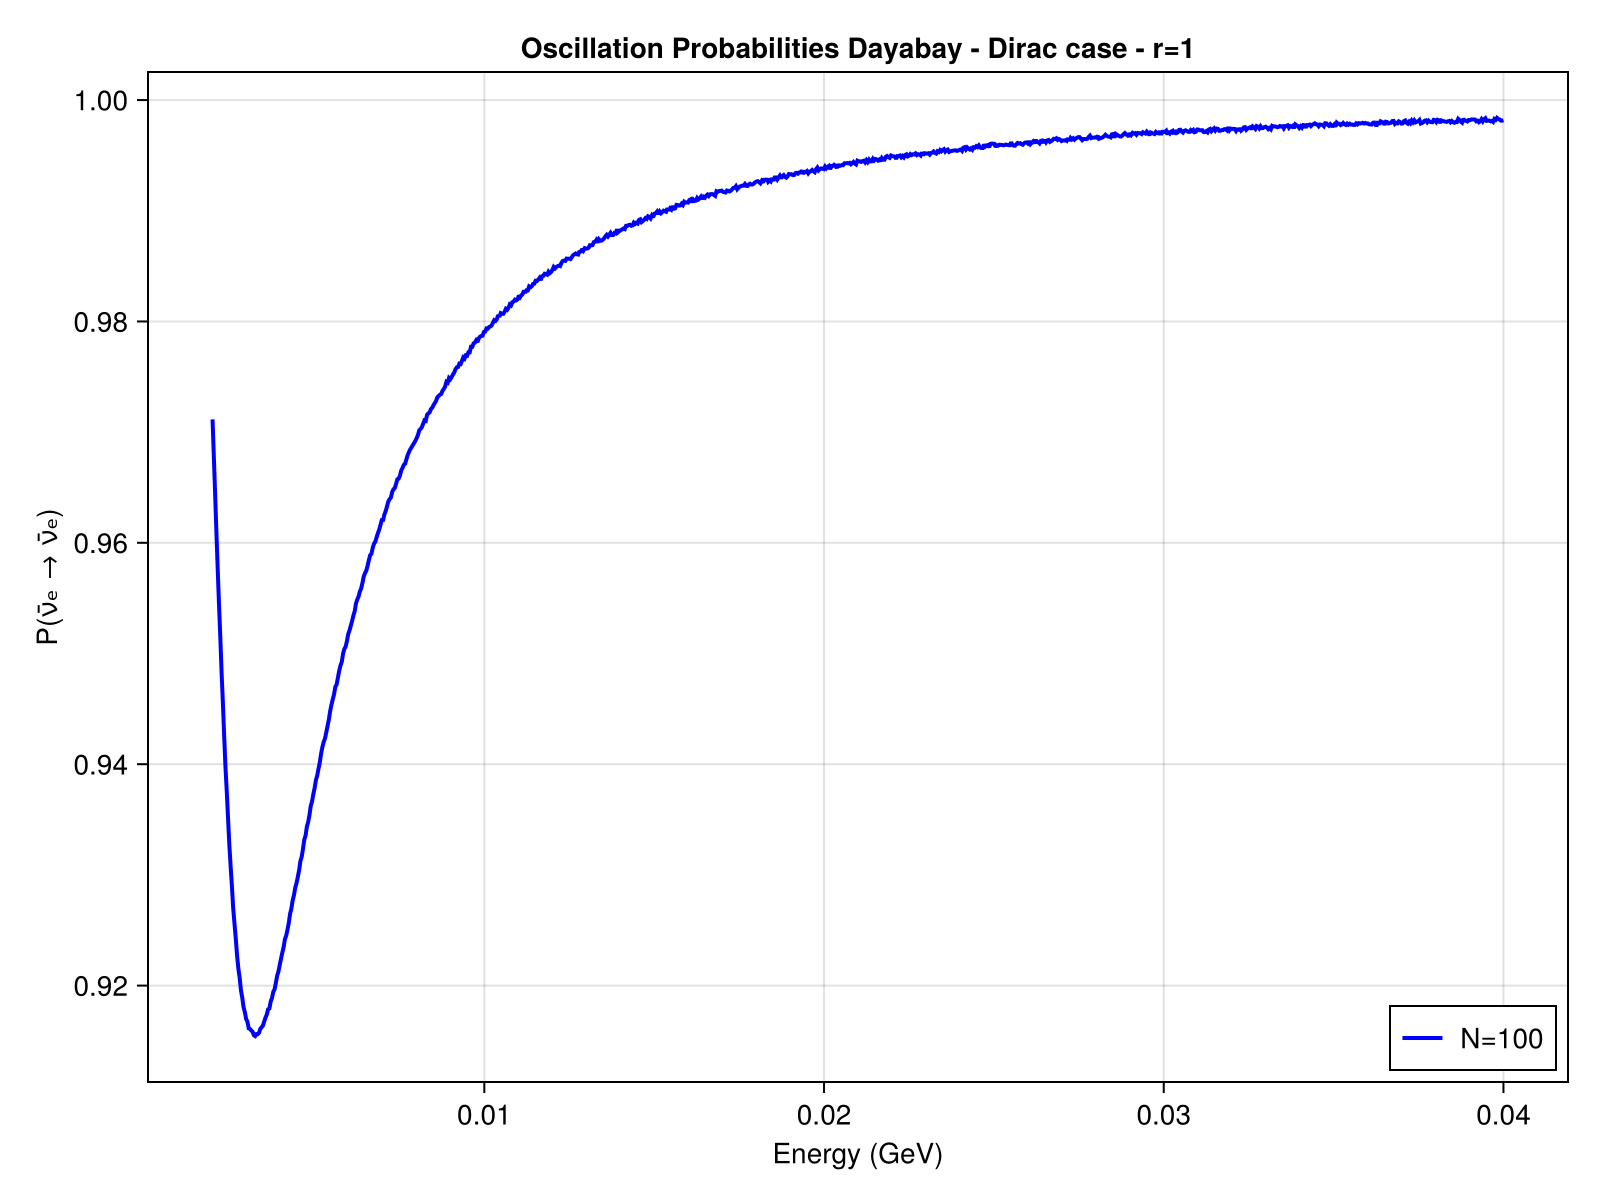

CairoMakie.Screen{IMAGE}


In [21]:
using CairoMakie
E_range = range(0.002, 0.04, length=1000) 
L=1.663
L_vec = [L]


osc_prob = Newtrinos.osc.get_osc_prob(osc_cfg)

p= Newtrinos.get_params(experiments)
p_5 = merge(p, (N = ftype(100),))


probab_5 = osc_prob(collect(E_range), L_vec, p_5; anti=true)

fig = Figure(size=(800, 600))
ax = Axis(fig[1,1], 
    xlabel = "Energy (GeV)",
    ylabel = "P(ν̄ₑ → ν̄ₑ)", 
    title = "Oscillation Probabilities Dayabay - Dirac case - r=1"
)

# Plot the lines
#lines!(ax, E_range, probab_SM[:, 1, 1,1], label="SM", linewidth=2, color=:green)
lines!(ax, E_range, probab_5[:, 1, 1,1], label=" N=100", linewidth=2, color=:blue)


# Add legend and set limits
axislegend(ax, position=:rb)

display(fig)


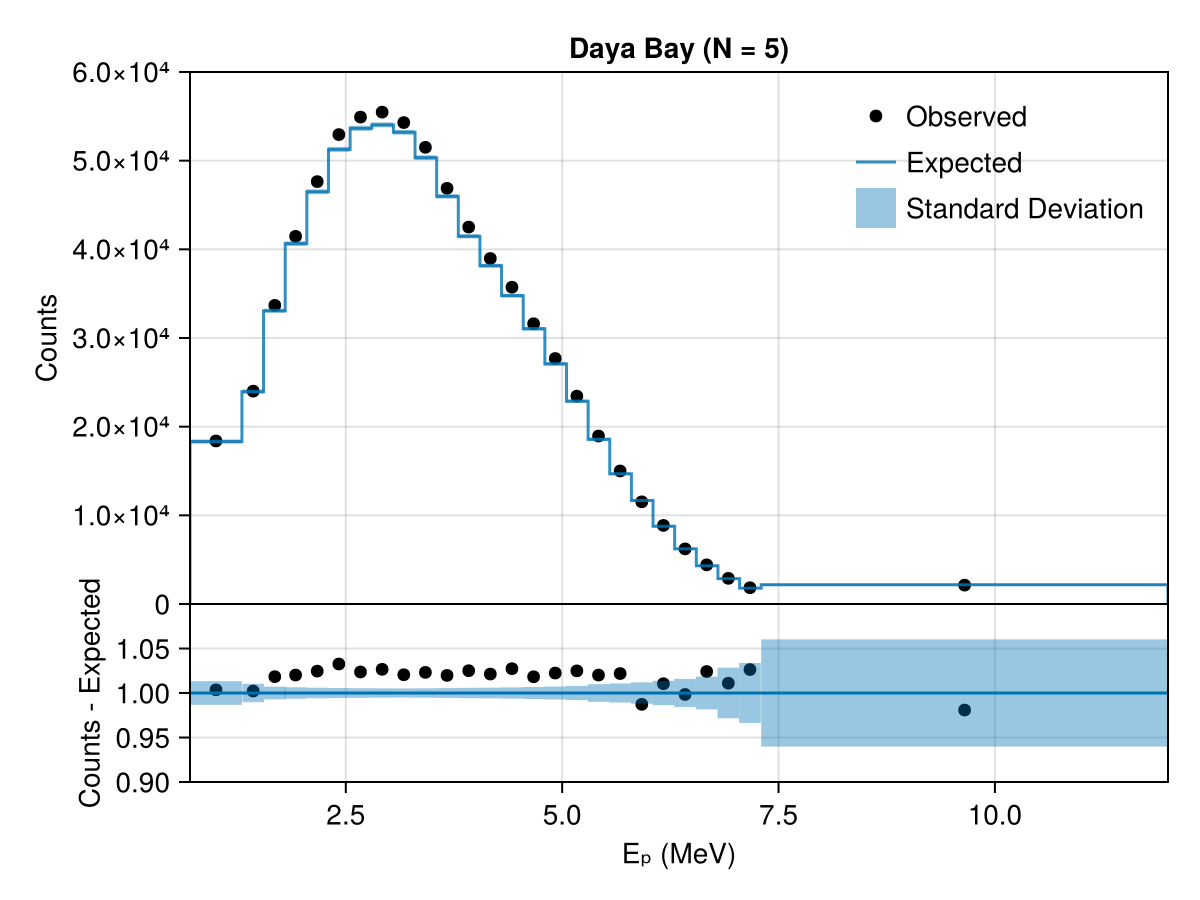

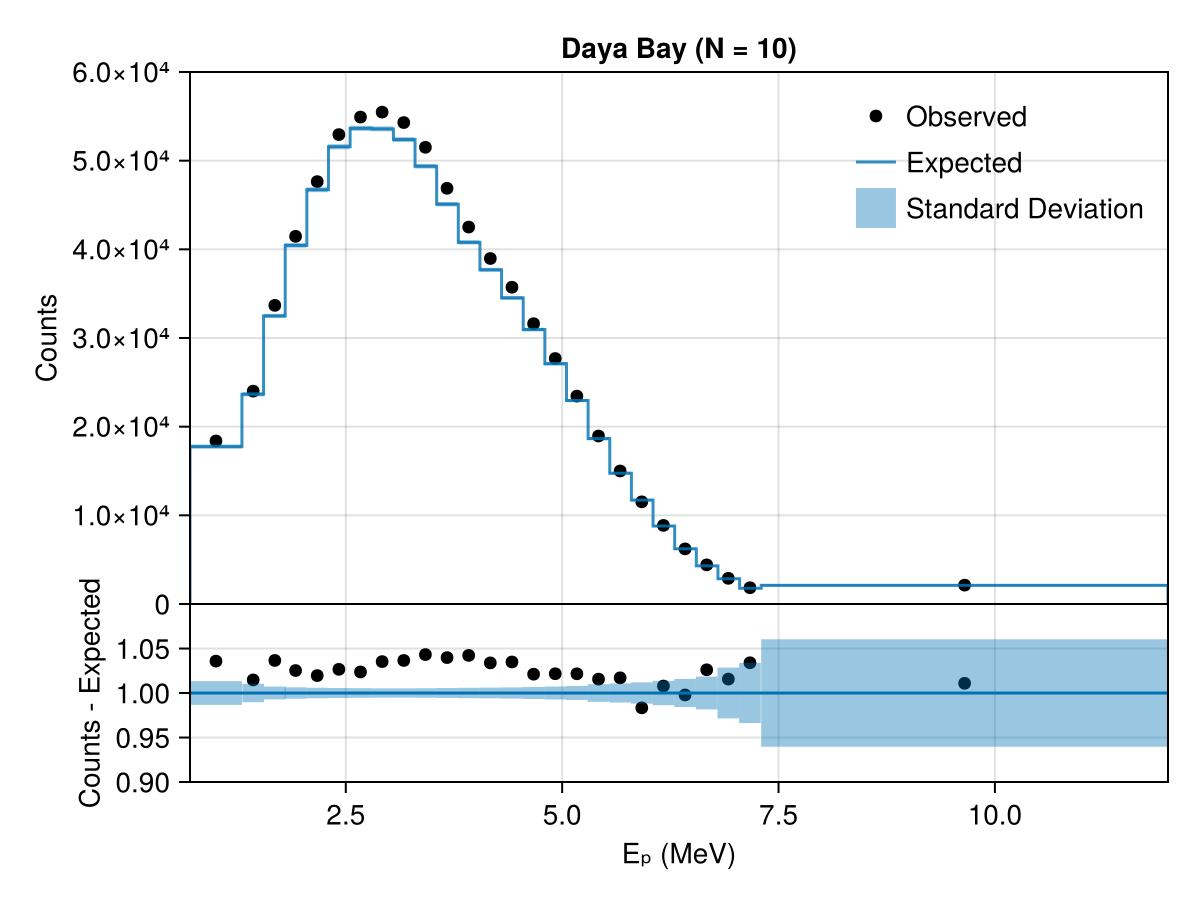

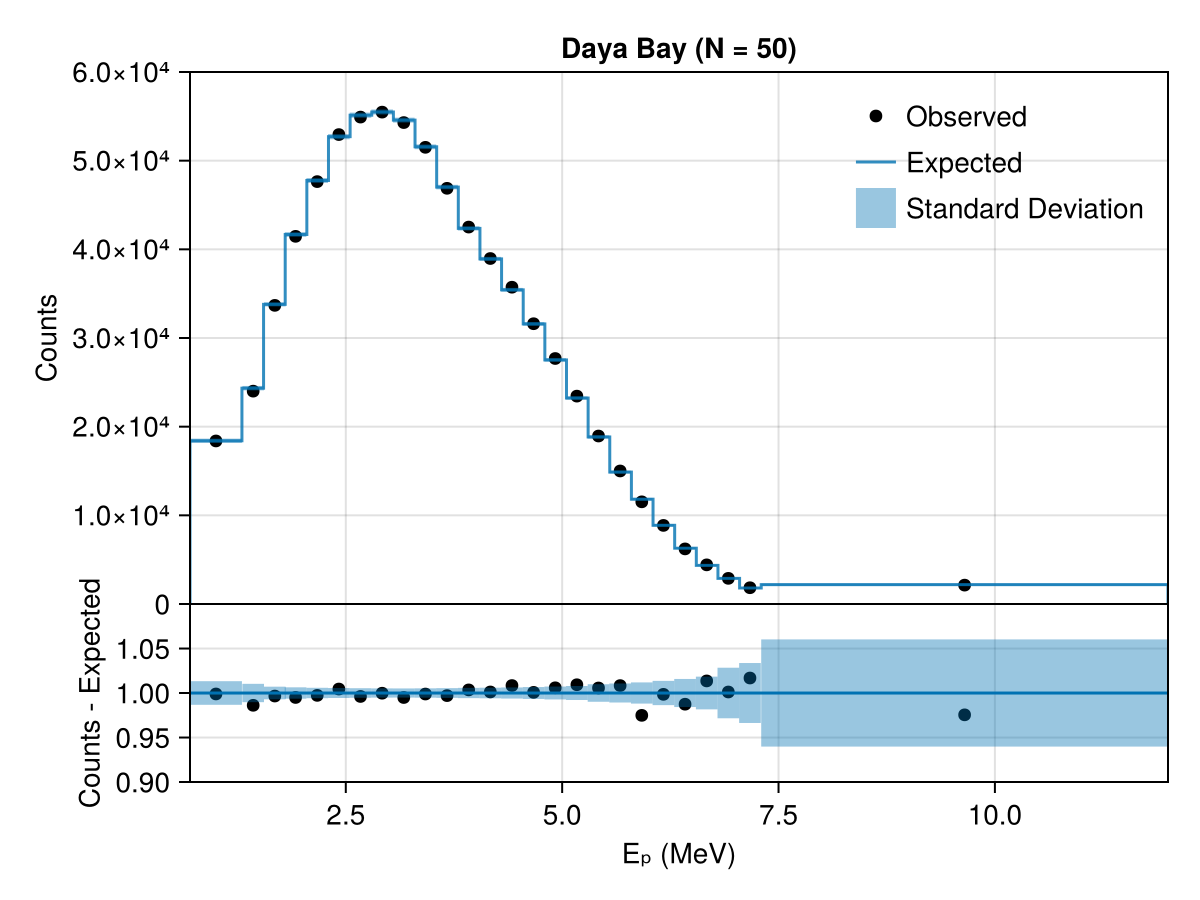

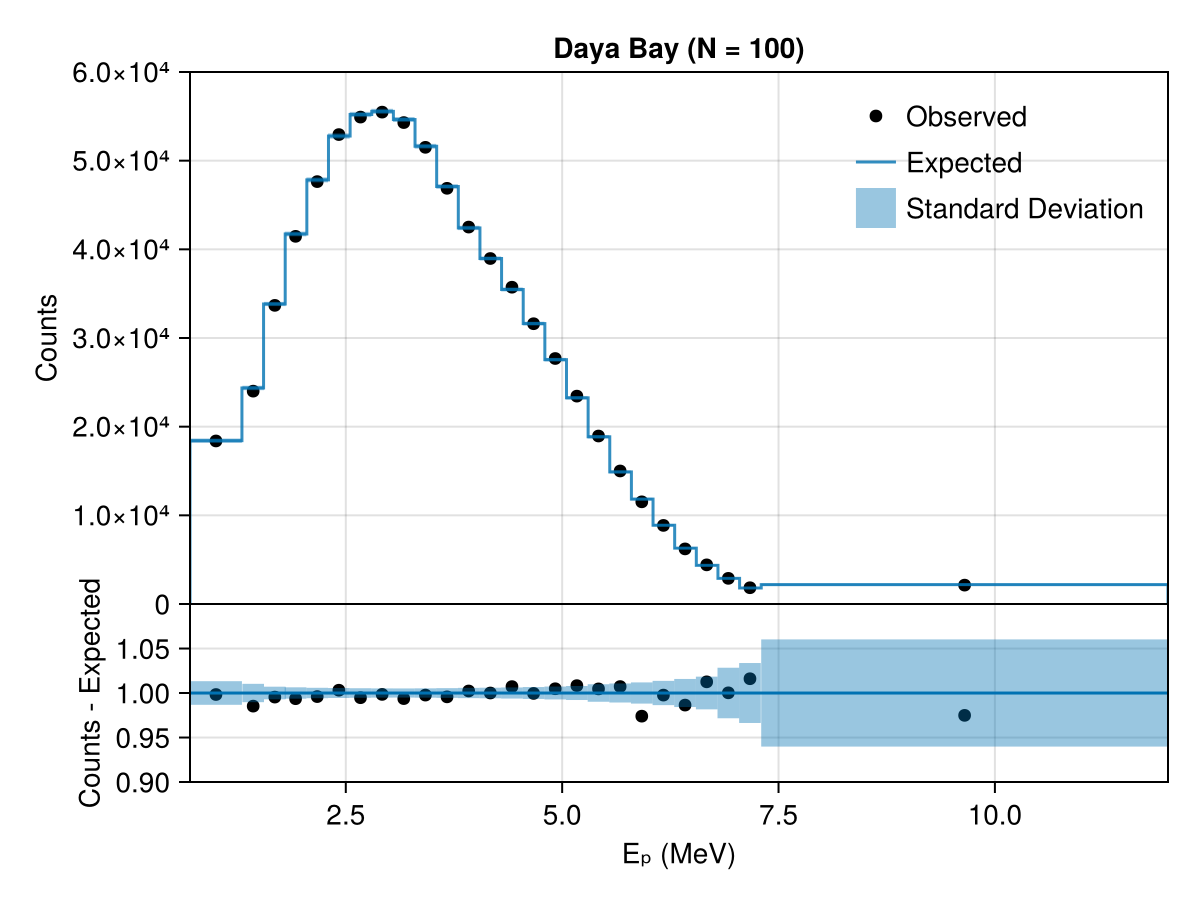

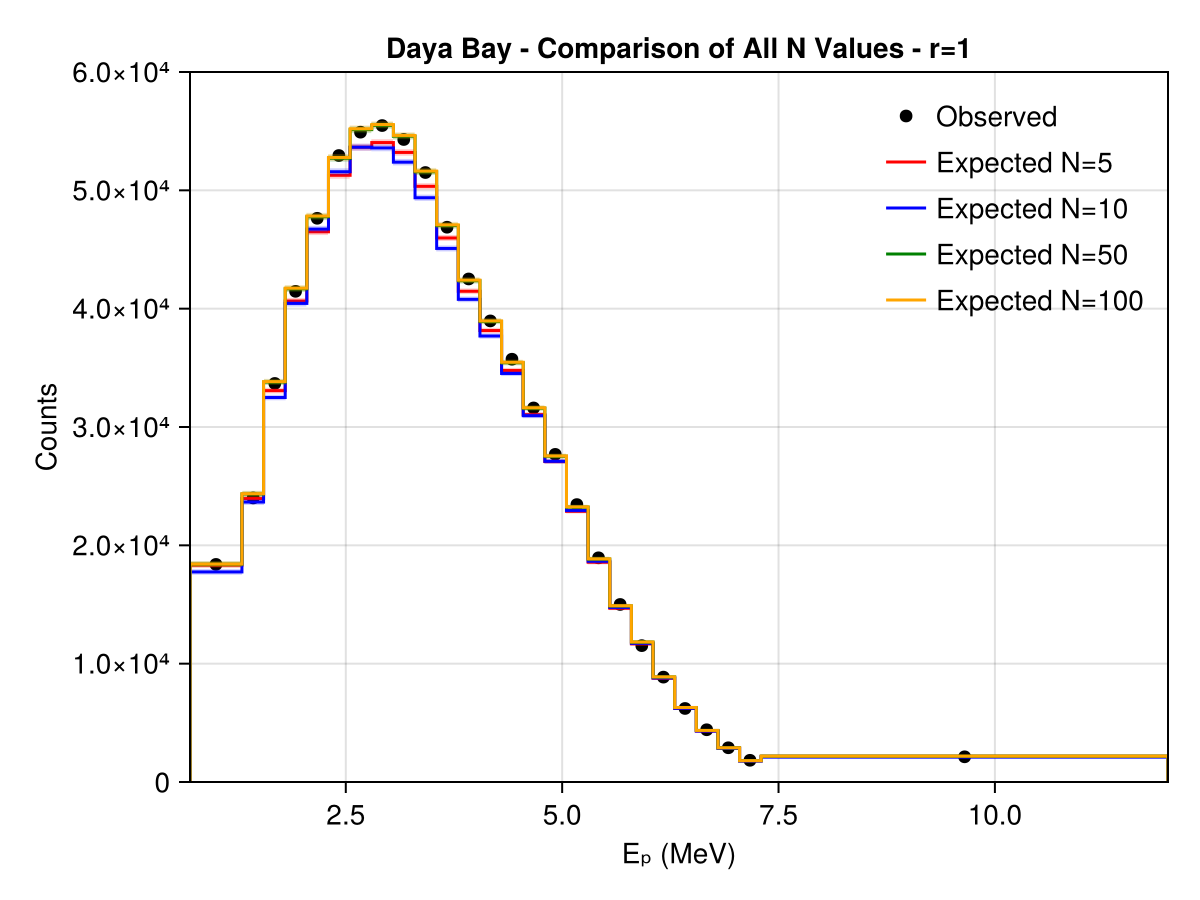

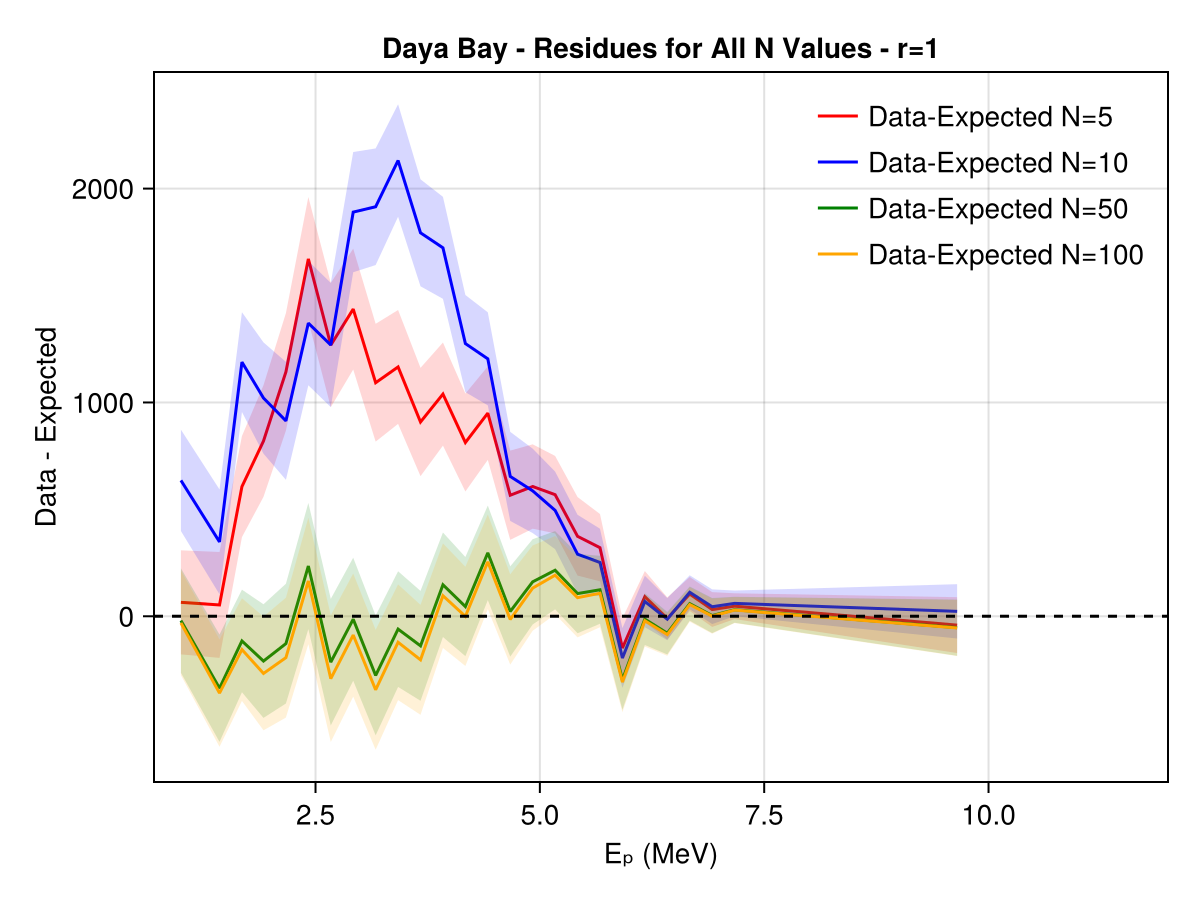

LoadError: SYSTEM: show(lasterr) caused an error

In [ ]:
img = experiments.dayabay.plot(p)
display("image/png", img)
#save("/home/sofialon/Newtrinos.jl/profiled plot/dayabay/dayabay_data_NND_100_0.png", img)

In [8]:

all_priors = Newtrinos.get_priors(experiments)


#vars_to_scan = (r=31,  m₀=31)  
vars_to_scan=(r=31, N=31)

modified_priors = (
    N = all_priors.N,
    m₀ =all_priors.m₀,
    r = all_priors.r,
    
   
  

    Δm²₂₁ = p.Δm²₂₁,  
    Δm²₃₁ =all_priors.Δm²₃₁ , 
    δCP = p.δCP,    
    θ₁₂ = p.θ₁₂,    
    θ₁₃= all_priors.θ₁₃,       
    θ₂₃ = p.θ₂₃   
    

)


(N = Uniform{Float64}(a=1.0, b=40.0), m₀ = Uniform{Float64}(a=0.001, b=2.0), r = Uniform{Float64}(a=1.0e-8, b=1.0), Δm²₂₁ = 7.53e-5, Δm²₃₁ = Uniform{Float64}(a=0.002, b=0.003), δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = Uniform{Float64}(a=0.1, b=0.2), θ₂₃ = 0.8556288707523761)

In [9]:

likelihood = Newtrinos.generate_likelihood(experiments);


In [10]:

result = Newtrinos.scan(likelihood, modified_priors, vars_to_scan, p)

Progress: 100%|█████████████████████████████████████████| Time: 0:10:35


NewtrinosResult((r = [1.0e-8, 0.033333343, 0.066666676, 0.100000009, 0.133333342, 0.166666675, 0.200000008, 0.233333341, 0.266666674, 0.30000000699999996  …  0.700000003, 0.733333336, 0.766666669, 0.8000000020000001, 0.8333333350000001, 0.866666668, 0.900000001, 0.9333333340000001, 0.966666667, 1.0], N = [1.0, 2.3, 3.6, 4.9, 6.2, 7.5, 8.8, 10.1, 11.4, 12.7  …  28.299999999999997, 29.599999999999998, 30.900000000000002, 32.2, 33.5, 34.800000000000004, 36.1, 37.4, 38.7, 40.0]), (m₀ = [0.1 0.1 … 0.1 0.1; 0.1 0.1 … 0.1 0.1; … ; 0.1 0.1 … 0.1 0.1; 0.1 0.1 … 0.1 0.1], Δm²₂₁ = [7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; … ; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5], Δm²₃₁ = [0.0024752999999999997 0.0024752999999999997 … 0.0024752999999999997 0.0024752999999999997; 0.0024752999999999997 0.0024752999999999997 … 0.0024752999999999997 0.0024752999999999997; … ; 0.0024752999999999997 0.0024752999999999997 … 0.0024752999999999997 0.002475299999

In [11]:
#JLD2.@save "scan_dayabay_Nr_80_NND_m0=0.01_new.jld2" result

In [12]:
using CairoMakie

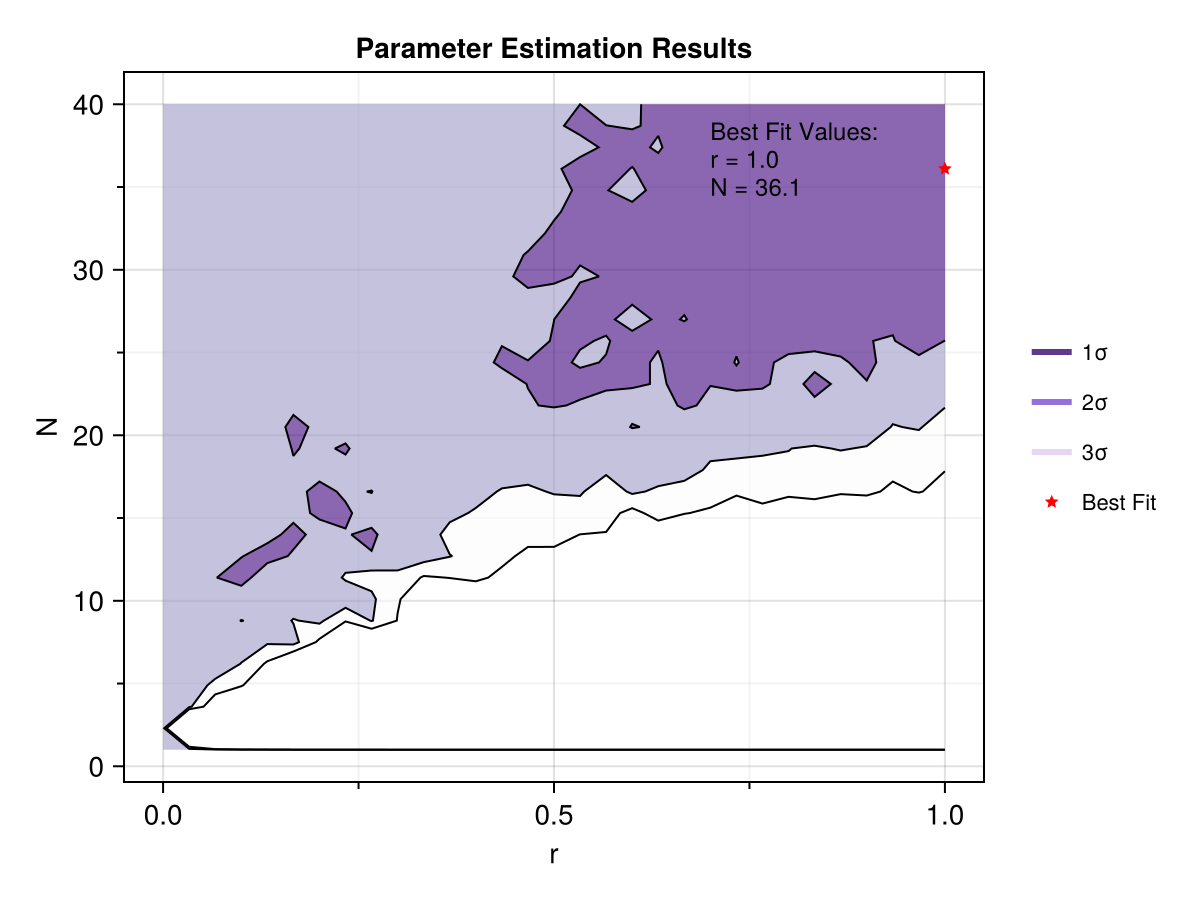

In [13]:
img = CairoMakie.plot(result)
display("image/png", img)
save("/home/sofialon/Newtrinos.jl/new_plots/dayabay/scan_dayabay_Nr_40_NND_m0.1_new.png", img)


┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


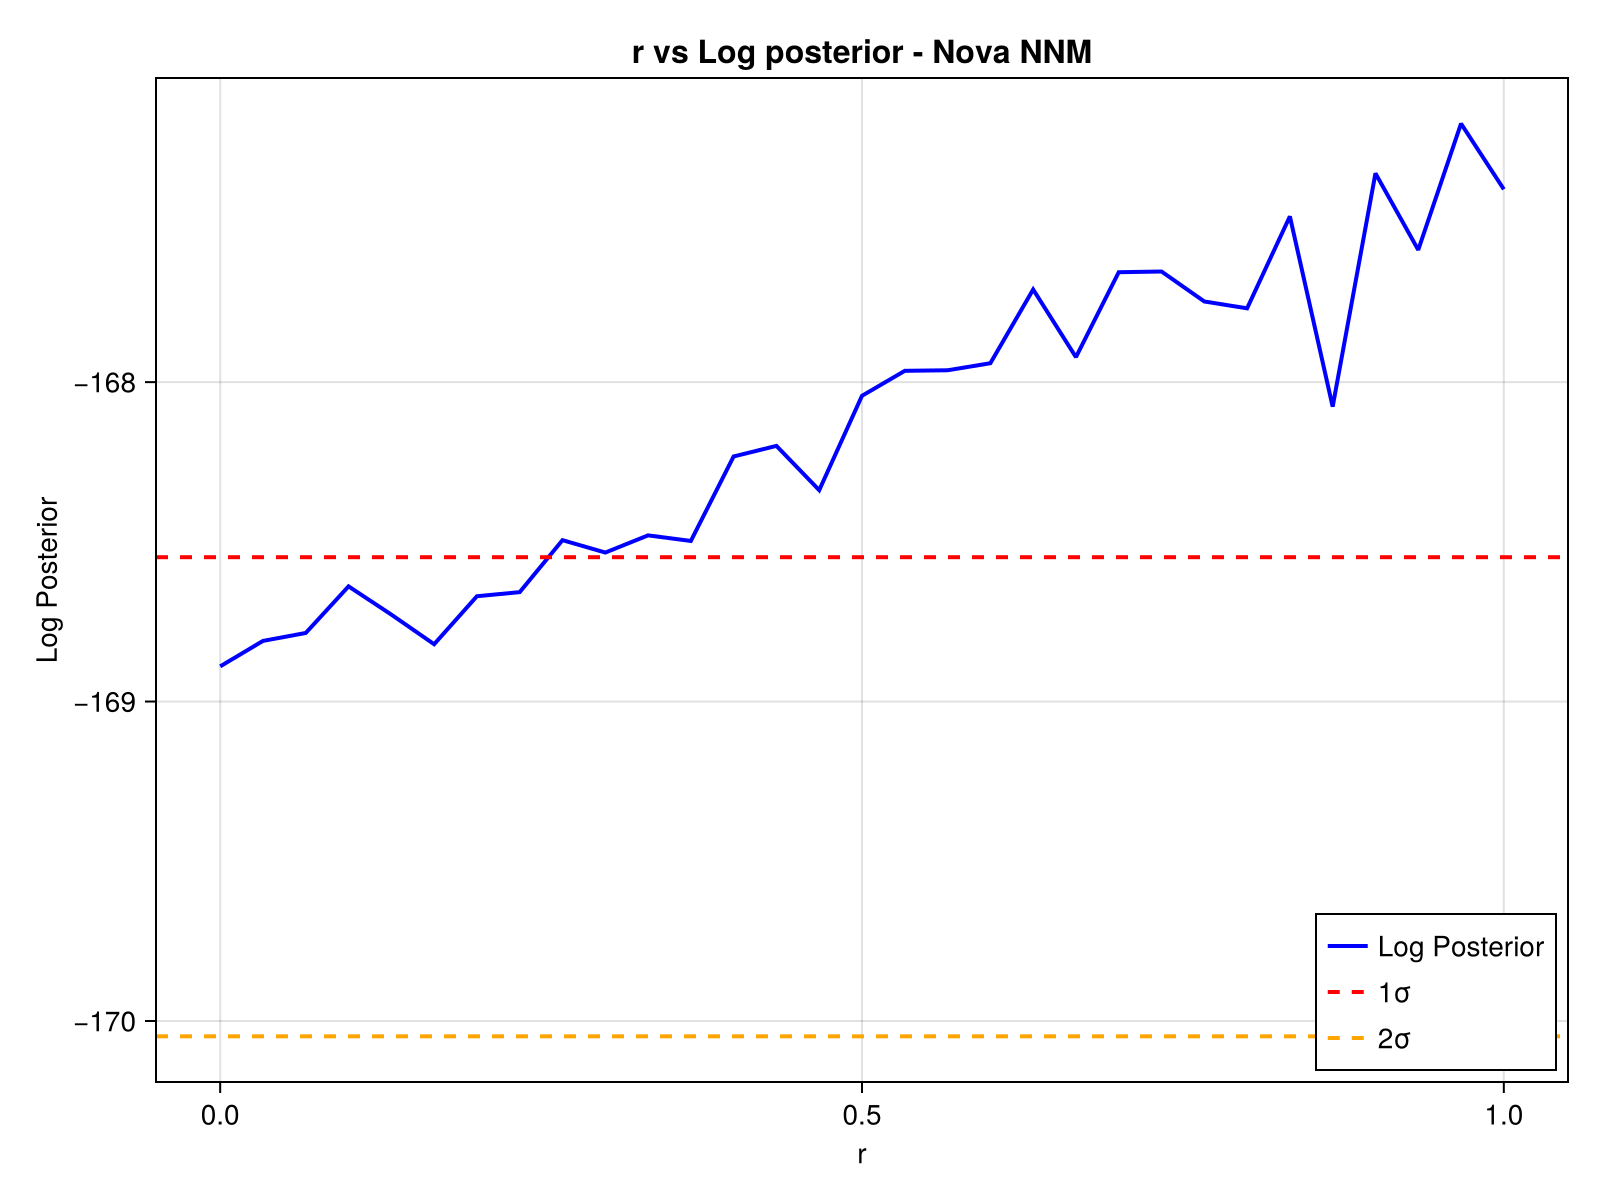

In [14]:
bf = Newtrinos.bestfit(result)

# Calculate confidence intervals
sigma_1_threshold = maximum(result.values.log_posterior[:, 15]) - 0.5
sigma_2_threshold = maximum(result.values.log_posterior[:, 15]) - 2.0

# Create the plot
fig = Figure(resolution = (800, 600))
ax = Axis(fig[1, 1],
    xlabel = "r",
    ylabel = "Log Posterior",
    title = "r vs Log posterior - Nova NNM",
    titlesize = 16,
    xlabelsize = 14,
    ylabelsize = 14
)

# Plot the main curve
lines!(ax, result.axes.r, result.values.log_posterior[:, 25],
    color = :blue,
    linewidth = 2,
    label = "Log Posterior"
)

# Add confidence level lines
hlines!(ax, [sigma_1_threshold], 
    color = :red, 
    linestyle = :dash, 
    linewidth = 2,
    label = "1σ"
)

hlines!(ax, [sigma_2_threshold], 
    color = :orange, 
    linestyle = :dash, 
    linewidth = 2,
    label = "2σ"
)

# Add legend
axislegend(ax, position = :rb)  # right bottom

display("image/png", fig)
#save("/home/sofialon/Newtrinos.jl/profiled plot/dayabay/dayabay_rLogpost_N=50_m0=0.1_NND.png", fig)


Oscillations


In [22]:

# STANDARD MODEL
E_range = range(0.002, 0.04, length=1000) 
L=1.663
L_vec = [L]

osc_cfg_SM = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.ThreeFlavour(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc_SM = Newtrinos.osc.configure(osc_cfg_SM)
 

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics_SM = (; osc=osc_SM, atm_flux, earth_layers);


experiments_SM = (
 
    dayabay = Newtrinos.dayabay.configure(physics_SM),
);

p_SM = Newtrinos.get_params(experiments_SM)

osc_prob_SM = Newtrinos.osc.get_osc_prob(osc_cfg_SM)


probab_SM = osc_prob_SM(collect(E_range), L_vec, p; anti=true)

[ Info: Loading dayabay data


1000×1×3×3 Array{Float64, 4}:
[:, :, 1, 1] =
 0.9717520812960653
 0.9683109007040173
 0.9648651711561107
 0.9614516539986672
 0.9581006425040238
 0.954836715800887
 0.9516794498955481
 0.948644075884838
 0.9457420805008407
 0.9429817476633987
 0.94036864212353
 0.9379060378509995
 0.9355952947774657
 ⋮
 0.9985934515549718
 0.9985961358673033
 0.9985988125173264
 0.9986014815341185
 0.9986041429466216
 0.9986067967836391
 0.9986094430738394
 0.9986120818457556
 0.9986147131277864
 0.998617336948196
 0.9986199533351169
 0.9986225623165482

[:, :, 2, 1] =
 0.005418083717743282
 0.006640561788994135
 0.007947011695303933
 0.009315085502218932
 0.01072495802678424
 0.012159222438124659
 0.013602747738296124
 0.015042513386734001
 0.016467432457965777
 0.017868171654777297
 0.019236974100273762
 0.02056748897953614
 0.02185461068877964
 ⋮
 0.000857674820230858
 0.0008560528141375867
 0.0008544353946927165
 0.0008528225446588595
 0.0008512142468793375
 0.000849610484277723
 0.0008480112398574

In [33]:
# NNATURALNESS WITH DIFFERENT N 


osc_prob = Newtrinos.osc.get_osc_prob(osc_cfg)

p= Newtrinos.get_params(experiments)
p_5 = merge(p, (N = ftype(5),))
p_10 = merge(p, (N = ftype(10),))
p_20 = merge(p, (N = ftype(20),))
p_50 = merge(p, (N = ftype(50),))

probab_5 = osc_prob(collect(E_range), L_vec, p_5; anti=true)
probab_10 = osc_prob(collect(E_range), L_vec, p_10; anti=true)
probab_20 = osc_prob(collect(E_range), L_vec, p_20; anti=true)
probab_50 = osc_prob(collect(E_range), L_vec, p_50; anti=true)

p_0 = merge(p, (r = ftype(1e-8),))
p_025 = merge(p,  (r = ftype(0.25),))
p_05 = merge(p,  (r = ftype(0.5),))
p_1 = merge(p,  (r = ftype(1),))


probab_0 = osc_prob(collect(E_range), L_vec, p_0; anti=true)
probab_025 = osc_prob(collect(E_range), L_vec, p_025; anti=true)
probab_05 = osc_prob(collect(E_range), L_vec, p_05; anti=true)
probab_1 = osc_prob(collect(E_range), L_vec, p_1; anti=true)


gamma[1.0, 1.0037579389474338, 1.1169288249481253]
scale0.1
Condition number: 532.9727391724375
gamma[1.0, 1.0037579389474338, 1.1169288249481253]
scale0.1
Condition number: 9151.448738628736
gamma[1.0, 1.0037579389474338, 1.1169288249481253]
scale0.1
Condition number: 152716.35383357923
gamma[1.0, 1.0037579389474338, 1.1169288249481253]
scale0.1
Condition number: 6.130551419523468e6
gamma[1.0, 1.0037579389474338, 1.1169288249481253]
scale0.1
Condition number: 1.4443023579972752e13
gamma[1.0, 1.0037579389474338, 1.1169288249481253]
scale0.1
Condition number: 586018.4862222135
gamma[1.0, 1.0037579389474338, 1.1169288249481253]
scale0.1
Condition number: 297155.71609635284
gamma[1.0, 1.0037579389474338, 1.1169288249481253]
scale0.1
Condition number: 152716.35383357923


1000×1×60×60 Array{Float64, 4}:
[:, :, 1, 1] =
 0.9598890458669962
 0.9589955718675142
 0.9541427446862172
 0.955131753582456
 0.9521936498996516
 0.945718771590042
 0.9465389560008227
 0.9447709269349955
 0.9408610018195889
 0.9317116638334978
 0.9279082336509828
 0.9233713284340872
 0.9228602094447301
 ⋮
 0.9899850909265866
 0.9919288688879215
 0.9916315776672223
 0.9912498811697096
 0.9898551540743152
 0.9916478298288407
 0.990506507276384
 0.9913300684743043
 0.9895274650002835
 0.9907311377396185
 0.9905099482332542
 0.9893486299787421

[:, :, 2, 1] =
 0.005441668067176242
 0.006775767301602088
 0.007723094437930785
 0.009152082341620186
 0.010429852493695439
 0.012175903753009278
 0.013413772662944447
 0.014818547919266931
 0.016130246072169823
 0.017716801606318704
 0.019011200455969345
 0.020557353756298587
 0.021586572094312823
 ⋮
 0.0008917234267169926
 0.0008001163750543051
 0.0009356075937454972
 0.0007748039909827593
 0.0008372138945229792
 0.0009194183103155211
 0.0008317

In [34]:
using CairoMakie

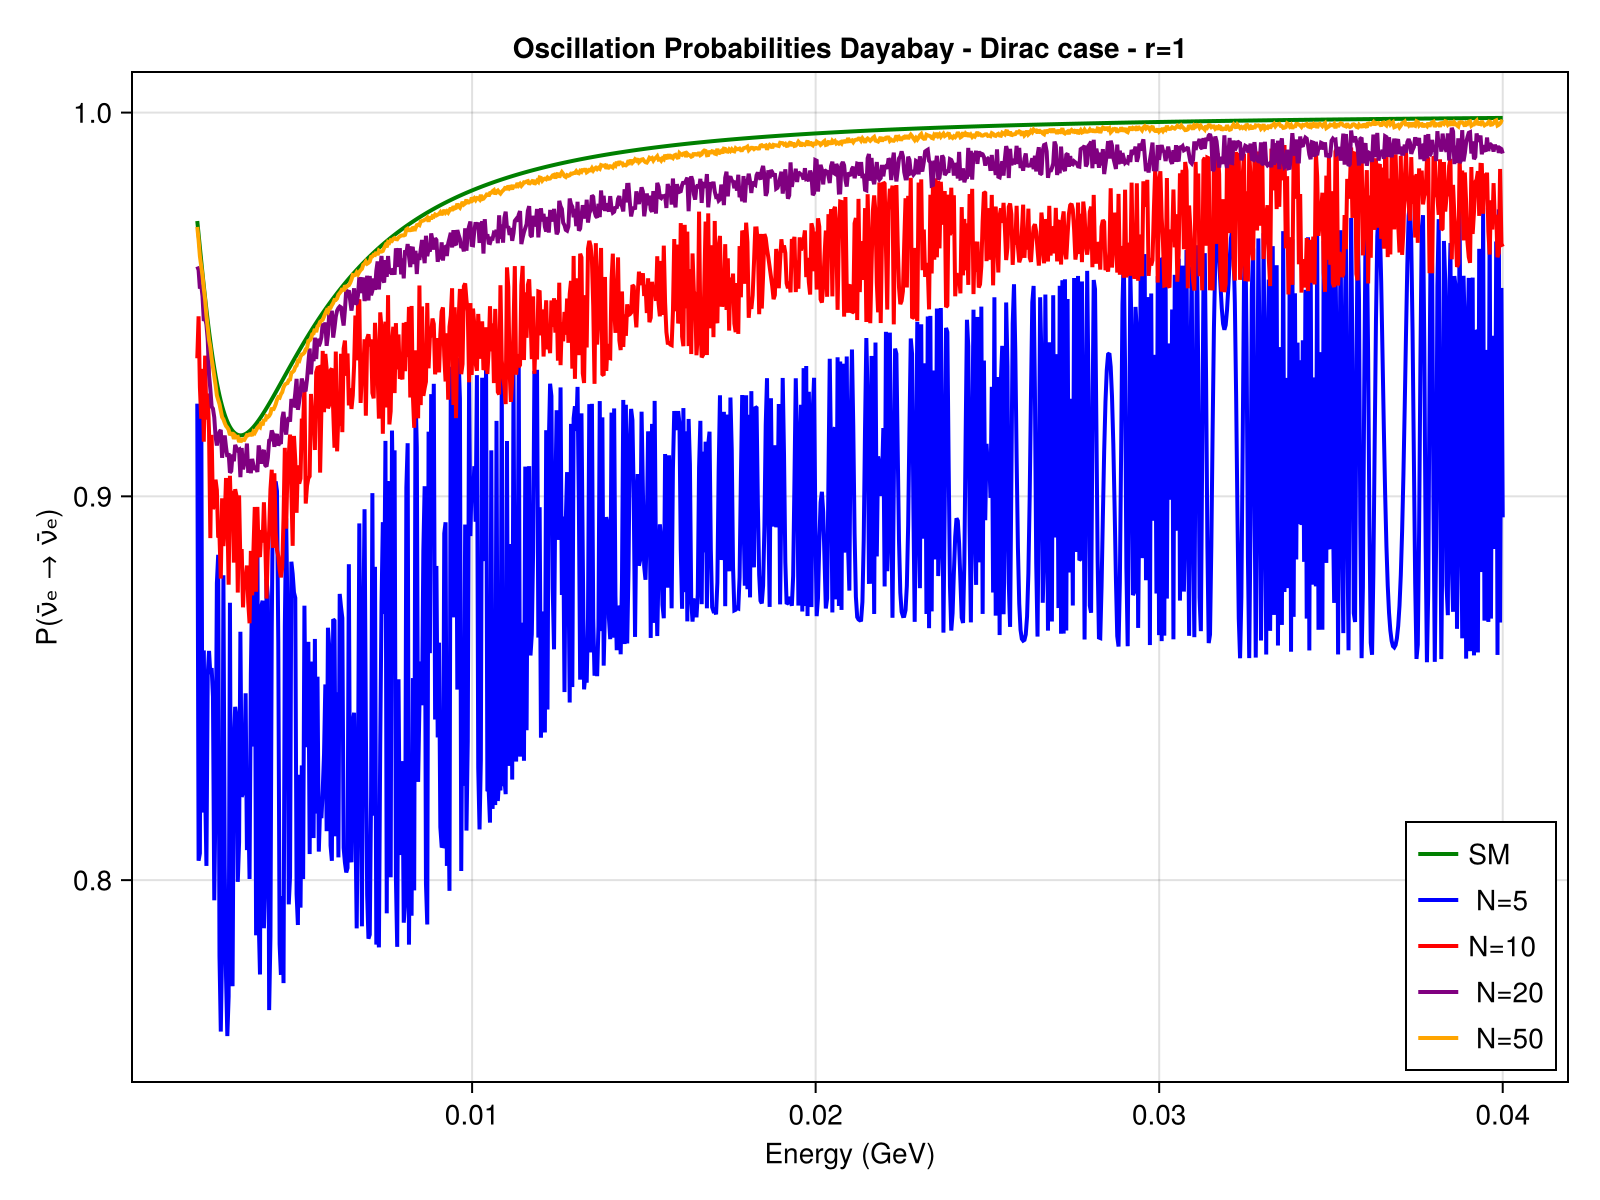

In [35]:

fig = Figure(size=(800, 600))
ax = Axis(fig[1,1], 
    xlabel = "Energy (GeV)",
    ylabel = "P(ν̄ₑ → ν̄ₑ)", 
    title = "Oscillation Probabilities Dayabay - Dirac case - r=1"
)

# Plot the lines
lines!(ax, E_range, probab_SM[:, 1, 1,1], label="SM", linewidth=2, color=:green)
lines!(ax, E_range, probab_5[:, 1, 1,1], label=" N=5", linewidth=2, color=:blue)
lines!(ax, E_range, probab_10[:, 1, 1,1], label="N=10", linewidth=2, color=:red)
lines!(ax, E_range, probab_20[:, 1,1,1], label=" N=20", linewidth=2, color=:purple)
lines!(ax, E_range, probab_50[:, 1,1,1], label=" N=50", linewidth=2, color=:orange)

# Add legend and set limits
axislegend(ax, position=:rb)
#save("/home/sofialon/Newtrinos.jl/natural plot/osc_dayabay_N_dirac.png", fig)

fig

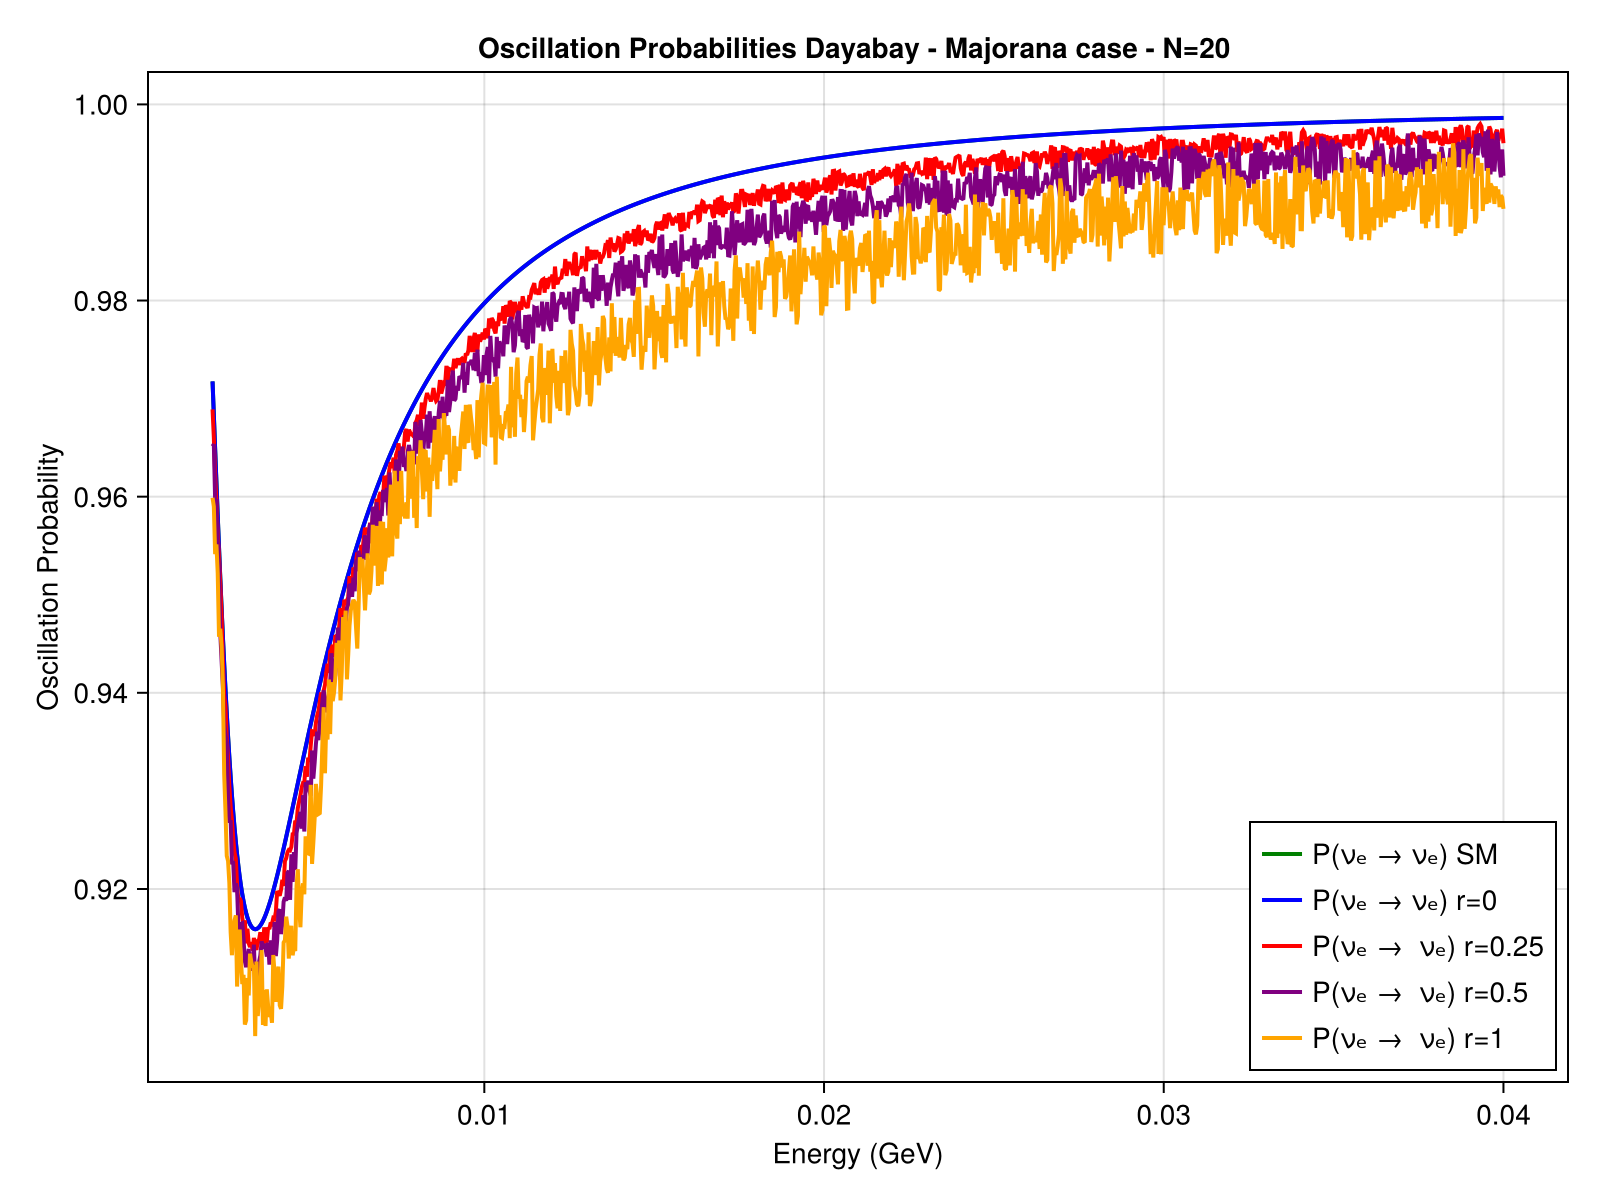

In [36]:

fig = Figure(size=(800, 600))
ax = Axis(fig[1,1], 
    xlabel = "Energy (GeV)",
    ylabel = "Oscillation Probability", 
    title = "Oscillation Probabilities Dayabay - Majorana case - N=20 "
)

# Plot the lines
lines!(ax, E_range, probab_SM[:, 1, 1, 1], label="P(νₑ → νₑ) SM", linewidth=2, color=:green)
lines!(ax, E_range, probab_0[:, 1, 1, 1], label="P(νₑ → νₑ) r=0", linewidth=2, color=:blue)
lines!(ax, E_range, probab_025[:, 1, 1, 1], label="P(νₑ →  νₑ) r=0.25", linewidth=2, color=:red)
lines!(ax, E_range, probab_05[:, 1, 1, 1], label="P(νₑ →  νₑ) r=0.5", linewidth=2, color=:purple)
lines!(ax, E_range, probab_1[:, 1, 1, 1], label="P(νₑ →  νₑ) r=1", linewidth=2, color=:orange)

# Add legend and set limits
axislegend(ax, position=:rb)
#save("/home/sofialon/Newtrinos.jl/natural plot/osc_dayabay_r_majorana.png", fig)

fig

In [37]:
# Trying to understand the r discontinuity


osc_prob = Newtrinos.osc.get_osc_prob(osc_cfg)

p= Newtrinos.get_params(experiments)

p_down = merge(p, (r = ftype(0.25),))
p_up = merge(p,  (r = ftype(0.5),))


probab_down = osc_prob(collect(E_range), L_vec, p_up; anti=true)
probab_up= osc_prob(collect(E_range), L_vec, p_down; anti=true)

f1= Newtrinos.osc.get_matrices(osc_cfg.flavour)
h_down, FinalUmatrix_down=f1(p_down)
h_up, FinalUmatrix_up=f1(p_up)

delta_h=h_up.-h_down

delta_final=FinalUmatrix_up.-FinalUmatrix_down

println(maximum(abs.(delta_h)))
println(minimum(abs.(delta_h)))

println(maximum(abs.(delta_final)))
println(minimum(abs.(delta_final)))

#print(delta_h)
#display(delta_final)

gamma[1.0, 1.0037579389474338, 1.1169288249481253]
scale0.1
Condition number: 297155.71609635284
gamma[1.0, 1.0037579389474338, 1.1169288249481253]
scale0.1
Condition number: 586018.4862222135
gamma[1.0, 1.0037579389474338, 1.1169288249481253]
scale0.1
Condition number: 586018.4862222135
gamma[1.0, 1.0037579389474338, 1.1169288249481253]
scale0.1
Condition number: 297155.71609635284
1.645813981522933
5.129660767674176e-7
15504.328439267236
0.0
